**Instalaciones**

In [1]:
!pip install roboflow kaggle -q

import os, zipfile, shutil, glob
from PIL import Image
from google.colab import files

print("Librerías cargadas sin problemas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 65.1 MB/s eta 0:00:00
Librerías cargadas sin problemas


**Estructura de carpetas**

In [2]:
WORK_DIR = '/content/tfm'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']
TARGET_SIZE = (224, 224)

for cls in CLASSES:
    os.makedirs(f'{WORK_DIR}/dataset/{cls}', exist_ok=True)
os.makedirs(f'{WORK_DIR}/raw', exist_ok=True)

print("Estructura de directorios lista:")
for cls in CLASSES:
    print(f"  {WORK_DIR}/dataset/{cls}")

Estructura de directorios lista:
  /content/tfm/dataset/fluido
  /content/tfm/dataset/congestion
  /content/tfm/dataset/accidente
  /content/tfm/dataset/obras


**Subir y descomprimir Cityscapes**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Ruta al zip de Cityscapes en mi Drive
ZIP_PATH = '/content/drive/MyDrive/leftImg8bit_trainvaltest.zip'

print("Descomprimiendo Cityscapes desde Drive, puede tardar unos minutos...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(f'{WORK_DIR}/raw/cityscapes')

print("Listo, el zip se queda en Drive")

cityscapes_root = f'{WORK_DIR}/raw/cityscapes/leftImg8bit'
for split in ['train', 'val', 'test']:
    split_path = f'{cityscapes_root}/{split}'
    if os.path.exists(split_path):
        print(f"  {split}: {len(os.listdir(split_path))} ciudades")
    else:
        print(f"  {split}: no encontrado, revisar ruta")

Mounted at /content/drive
Descomprimiendo Cityscapes desde Drive, puede tardar unos minutos...
Listo, el zip se queda en Drive
  train: 18 ciudades
  val: 3 ciudades
  test: 6 ciudades


**Cityscapes → clase fluido**

In [4]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

counter = 0
MAX_FLUIDO_CITYSCAPES = 600

for split in ['train', 'val', 'test']:
    split_path = f'{cityscapes_root}/{split}'
    if not os.path.exists(split_path):
        continue
    for city in sorted(os.listdir(split_path)):
        city_path = f'{split_path}/{city}'
        if not os.path.isdir(city_path):
            continue
        for img_file in sorted(os.listdir(city_path)):
            if counter >= MAX_FLUIDO_CITYSCAPES:
                break
            if not img_file.endswith('.png'):
                continue
            src = f'{city_path}/{img_file}'
            if not is_valid_image(src):
                print(f"  Imagen corrupta, me la salto: {img_file}")
                continue
            dst = f'{WORK_DIR}/dataset/fluido/cityscapes_{counter:05d}.jpg'
            with Image.open(src) as img:
                img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
            counter += 1
        if counter >= MAX_FLUIDO_CITYSCAPES:
            break

print(f"Cityscapes procesado: {counter} imágenes para la clase fluido")

Cityscapes procesado: 600 imágenes para la clase fluido


**Kaggle: descargar Traffic Density Singapore**

In [5]:
import json

kaggle_creds = {
    "username": "Yushetf",
    "key": "KGAT_e52d98a98e4b09536184b85035faacbd"
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json
print("Credenciales de Kaggle configuradas")

print("Descargando Traffic Density Singapore...")
!kaggle datasets download -d rahat52/traffic-density-singapore \
    -p {WORK_DIR}/raw/singapore --unzip

singapore_root = f'{WORK_DIR}/raw/singapore'
print("\nEstructura del dataset descargado:")
for root, dirs, fnames in os.walk(singapore_root):
    level = root.replace(singapore_root, '').count(os.sep)
    if level < 3:
        n_imgs = len([f for f in fnames if f.lower().endswith(('.jpg','.jpeg','.png'))])
        indent = '  ' * level
        label = f"  ({n_imgs} imgs)" if n_imgs > 0 else ""
        print(f"{indent}{os.path.basename(root)}/{label}")

Credenciales de Kaggle configuradas
Descargando Traffic Density Singapore...
Dataset URL: https://www.kaggle.com/datasets/rahat52/traffic-density-singapore
License(s): GNU Free Documentation License 1.3
100% 222M/222M [00:14<00:00, 15.8MB/s]


Estructura del dataset descargado:
singapore/
  Final Dataset/
    testing/
    validation/
    training/


**Singapore → fluido y congestion**

In [6]:
# Mapeo entre las carpetas de Singapore y las 4 clases
# Los nombres exactos salen del output de la celda anterior
SINGAPORE_MAP = {
    'empty':       'fluido',
    'low':         'fluido',
    'medium':      'fluido',
    'high':        'congestion',
    'traffic Jam': 'congestion',
}

counters_sg = {'fluido': 0, 'congestion': 0}

for root, dirs, fnames in os.walk(singapore_root):
    folder = os.path.basename(root).lower().strip()
    clase = SINGAPORE_MAP.get(folder)
    if clase is None:
        continue
    for fname in fnames:
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        src = os.path.join(root, fname)
        if not is_valid_image(src):
            continue
        n = counters_sg[clase]
        dst = f'{WORK_DIR}/dataset/{clase}/singapore_{n:05d}.jpg'
        with Image.open(src) as img:
            img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
        counters_sg[clase] += 1

print("Singapore procesado:")
for k, v in counters_sg.items():
    print(f"  {k}: {v} imágenes")

Singapore procesado:
  fluido: 3286 imágenes
  congestion: 480 imágenes


**Roboflow: descargar accidentes y obras**

In [7]:
from roboflow import Roboflow

API_KEY = "kdf00f3HMaycoX24Td4q"
rf = Roboflow(api_key=API_KEY)

# Descargo en formato yolov8, solo interesan las imágenes no las anotaciones
print("Descargando dataset de accidentes...")
project_crash = rf.workspace("smith-fsuvw").project("car-crash-vjfyg")
dataset_crash = project_crash.version(1).download(
    "yolov8", location=f'{WORK_DIR}/raw/roboflow_accidente')

print("\nDescargando dataset de obras...")
project_obras = rf.workspace("bus-hclqm").project("road-construction-ve7zd")
dataset_obras = project_obras.version(1).download(
    "yolov8", location=f'{WORK_DIR}/raw/roboflow_obras')

print("\nDescargas completadas")

Descargando dataset de accidentes...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/tfm/raw/roboflow_accidente in yolov8:: 100%|██████████| 185/185 [00:00<00:00, 7179.57it/s]


Descargando dataset de obras...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/tfm/raw/roboflow_obras in yolov8:: 100%|██████████| 424/424 [00:00<00:00, 2408.02it/s]



Descargas completadas


**Explorar carpetas Roboflow antes de mapear**

In [8]:
for nombre, ruta in [('ACCIDENTE', f'{WORK_DIR}/raw/roboflow_accidente'),
                     ('OBRAS',     f'{WORK_DIR}/raw/roboflow_obras')]:
    print(f"\n── {nombre} ──")
    for root, dirs, fnames in os.walk(ruta):
        n = len([f for f in fnames if f.lower().endswith(('.jpg','.jpeg','.png'))])
        if n > 0:
            nivel = root.replace(ruta, '')
            print(f"  {nivel}  →  {n} imágenes")


── ACCIDENTE ──
  /train/images  →  60 imágenes
  /valid/images  →  17 imágenes
  /test/images  →  13 imágenes

── OBRAS ──
  /train/images  →  209 imágenes


**Roboflow → accidente y obras**

In [9]:
counters_rf = {'accidente': 0, 'obras': 0}

# Tuplas (ruta_raw, clase_destino)
FUENTES = [
    (f'{WORK_DIR}/raw/roboflow_accidente', 'accidente'),
    (f'{WORK_DIR}/raw/roboflow_obras',     'obras'),
]

for ruta_raw, clase in FUENTES:
    for root, dirs, fnames in os.walk(ruta_raw):
        # Solo proceso la carpeta images/, las labels no me hacen falta
        if not root.endswith('images'):
            continue
        for fname in fnames:
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            src = os.path.join(root, fname)
            if not is_valid_image(src):
                continue
            n = counters_rf[clase]
            dst = f'{WORK_DIR}/dataset/{clase}/roboflow_{n:05d}.jpg'
            with Image.open(src) as img:
                img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
            counters_rf[clase] += 1

print("Roboflow procesado:")
for k, v in counters_rf.items():
    print(f"  {k}: {v} imágenes")

Roboflow procesado:
  accidente: 90 imágenes
  obras: 209 imágenes


**Resumen final y diagnóstico**

In [10]:
print("=" * 40)
print("  ESTADO DEL DATASET - DIA 1")
print("=" * 40)

total = 0
minimo = float('inf')
clase_minima = ''

for cls in CLASSES:
    path = f'{WORK_DIR}/dataset/{cls}'
    n = len([f for f in os.listdir(path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total += n
    if n < minimo:
        minimo = n
        clase_minima = cls
    barra = '█' * (n // 30)
    print(f"  {cls:<12} {n:>5}  {barra}")

print("-" * 40)
print(f"  {'TOTAL':<12} {total:>5}")
print()

ratio = max(
    len(os.listdir(f'{WORK_DIR}/dataset/{c}')) for c in CLASSES
) / max(minimo, 1)

if ratio > 5:
    print(f"Desbalanceo importante (ratio {ratio:.1f}x)")
    print(f"  La clase '{clase_minima}' va a necesitar bastante augmentation")
elif ratio > 2:
    print(f"Desbalanceo moderado (ratio {ratio:.1f}x)")
    print(f"  Con augmentation estandar deberia ser suficiente")
else:
    print(f"Dataset bastante equilibrado (ratio {ratio:.1f}x)")

  ESTADO DEL DATASET - DIA 1
  fluido        3886  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  congestion     480  ████████████████
  accidente       90  ███
  obras          209  ██████
----------------------------------------
  TOTAL         4665

Desbalanceo importante (ratio 43.2x)
  La clase 'accidente' va a necesitar bastante augmentation


**Instalaciones y variables**

In [11]:
!pip install albumentations -q

import os, shutil, random, numpy as np
from PIL import Image
import albumentations as A
import cv2

WORK_DIR = '/content/tfm'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']
TARGET_SIZE = (224, 224)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Cuantas imágenes quiero por clase tras el equilibrado
TARGETS = {
    'fluido':     800,
    'congestion': 600,
    'accidente':  450,
    'obras':      450,
}

print("Todo cargado")

Todo cargado


**Recortar fluido a 800 imágenes**

In [12]:
fluido_path = f'{WORK_DIR}/dataset/fluido'
todas = [f for f in os.listdir(fluido_path)
         if f.lower().endswith(('.jpg','.jpeg','.png'))]

random.shuffle(todas)
mantener = set(todas[:800])

eliminadas = 0
for f in todas:
    if f not in mantener:
        os.remove(f'{fluido_path}/{f}')
        eliminadas += 1

print(f"fluido recortado: {eliminadas} imágenes eliminadas")
print(f"  Quedan: {len(os.listdir(fluido_path))} imágenes")

fluido recortado: 3086 imágenes eliminadas
  Quedan: 800 imágenes


**Pipeline de augmentation**


In [13]:
aug_agresivo = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussNoise(p=0.4),
    A.RandomFog(fog_coef_range=(0.1, 0.3), p=0.3),
    A.RandomRain(slant_range=(-10, 10), p=0.2),
    A.CLAHE(p=0.3),
    A.Resize(224, 224),
])

# Para congestion no hace falta ser tan agresivo
aug_moderado = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=0.4),
    A.Rotate(limit=10, p=0.4),
    A.GaussNoise(p=0.3),
    A.Resize(224, 224),
])


def augmentar_clase(clase, pipeline, objetivo):
    path = f'{WORK_DIR}/dataset/{clase}'
    originales = [f for f in os.listdir(path)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
    n_actual = len(originales)
    necesarias = objetivo - n_actual

    if necesarias <= 0:
        print(f"  {clase}: ya tiene {n_actual} imágenes, no toco nada")
        return

    generadas = 0
    idx = 0
    while generadas < necesarias:
        src = f'{path}/{originales[idx % len(originales)]}'
        img = cv2.imread(src)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = pipeline(image=img)['image']
        dst = f'{path}/aug_{generadas:05d}.jpg'
        cv2.imwrite(dst, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, 90])
        generadas += 1
        idx += 1

    print(f"  {clase}: {n_actual} -> {n_actual + generadas} imágenes (+{generadas} sintéticas)")

print("Pipelines de augmentation listos")

Pipelines de augmentation listos


**Aplicar augmentation por clase**

In [14]:
print("Generando imágenes sintéticas...")
augmentar_clase('accidente',  aug_agresivo,  TARGETS['accidente'])
augmentar_clase('obras',      aug_moderado,  TARGETS['obras'])
augmentar_clase('congestion', aug_moderado,  TARGETS['congestion'])

print("\nAugmentation completado")
print("\nRecuento final:")
for cls in CLASSES:
    n = len([f for f in os.listdir(f'{WORK_DIR}/dataset/{cls}')
             if f.lower().endswith(('.jpg','.jpeg','.png'))])
    barra = '█' * (n // 30)
    print(f"  {cls:<12} {n:>5}  {barra}")

Generando imágenes sintéticas...
  accidente: 90 -> 450 imágenes (+360 sintéticas)
  obras: 209 -> 450 imágenes (+241 sintéticas)
  congestion: 480 -> 600 imágenes (+120 sintéticas)

Augmentation completado

Recuento final:
  fluido         800  ██████████████████████████
  congestion     600  ████████████████████
  accidente      450  ███████████████
  obras          450  ███████████████


**Split train/val/test (80/10/10)**

In [15]:
SPLIT_DIR = f'{WORK_DIR}/dataset_split'

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(f'{SPLIT_DIR}/{split}/{cls}', exist_ok=True)

counters_split = {s: {c: 0 for c in CLASSES} for s in ['train','val','test']}

for cls in CLASSES:
    imgs = [f for f in os.listdir(f'{WORK_DIR}/dataset/{cls}')
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(imgs)

    n = len(imgs)
    n_val  = max(1, int(n * 0.10))
    n_test = max(1, int(n * 0.10))
    n_train = n - n_val - n_test

    splits_map = (
        [('train', f) for f in imgs[:n_train]] +
        [('val',   f) for f in imgs[n_train:n_train+n_val]] +
        [('test',  f) for f in imgs[n_train+n_val:]]
    )

    for split, fname in splits_map:
        src = f'{WORK_DIR}/dataset/{cls}/{fname}'
        dst = f'{SPLIT_DIR}/{split}/{cls}/{fname}'
        shutil.copy2(src, dst)
        counters_split[split][cls] += 1

print("Split 80/10/10 completado:\n")
print(f"  {'':12} {'train':>6} {'val':>6} {'test':>6}")
print(f"  {'-'*32}")
for cls in CLASSES:
    t = counters_split['train'][cls]
    v = counters_split['val'][cls]
    te = counters_split['test'][cls]
    print(f"  {cls:<12} {t:>6} {v:>6} {te:>6}")

Split 80/10/10 completado:

                train    val   test
  --------------------------------
  fluido          640     80     80
  congestion      480     60     60
  accidente       360     45     45
  obras           360     45     45


**Verificación visual (muestra 1 imagen por clase)**

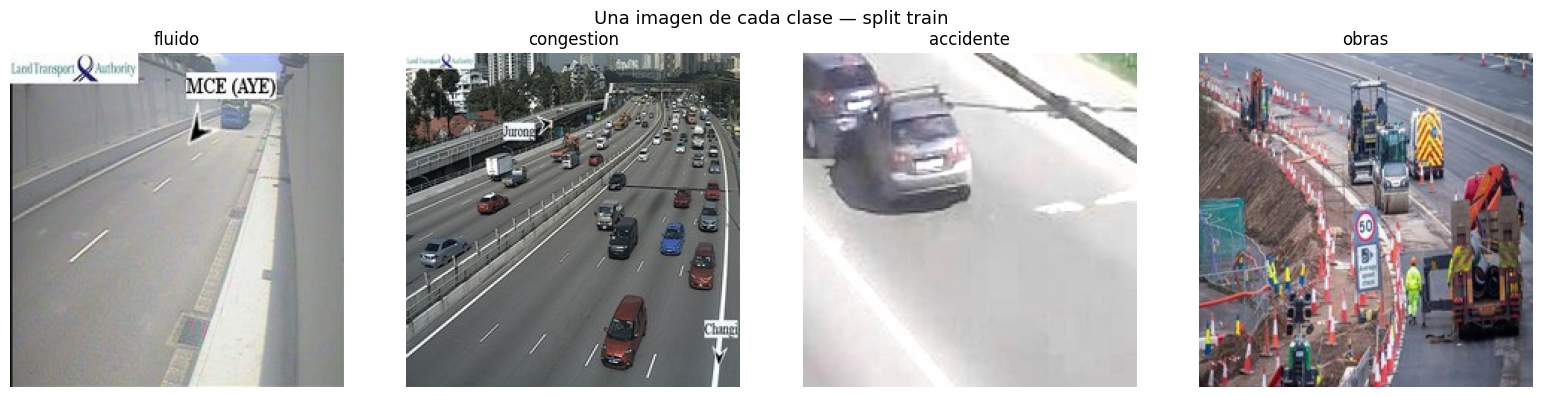

Comprobación visual ok


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Una imagen de cada clase — split train', fontsize=13)

for i, cls in enumerate(CLASSES):
    path = f'{SPLIT_DIR}/train/{cls}'
    sample = random.choice(os.listdir(path))
    img = Image.open(f'{path}/{sample}')
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print("Comprobación visual ok")

**Guardar dataset_split en Drive**

In [17]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DEST = '/content/drive/MyDrive/TFM/dataset_split'

if os.path.exists(DRIVE_DEST):
    shutil.rmtree(DRIVE_DEST)

print("Guardando dataset_split en Drive, un momento...")
shutil.copytree(SPLIT_DIR, DRIVE_DEST)

print("Guardado correctamente")
print("\nVerificación:")
total = 0
for split in ['train', 'val', 'test']:
    n = sum(
        len(os.listdir(f'{DRIVE_DEST}/{split}/{cls}'))
        for cls in CLASSES
    )
    total += n
    print(f"  {split}: {n} imágenes")
print(f"  TOTAL: {total} imágenes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Guardando dataset_split en Drive, un momento...
Guardado correctamente

Verificación:
  train: 1840 imágenes
  val: 230 imágenes
  test: 230 imágenes
  TOTAL: 2300 imágenes


**Instalaciones y verificación de GPU**

In [18]:
!pip install torchvision -q

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os, time, copy
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Sin GPU detectada, activar en Entorno de ejecución > Cambiar tipo de entorno")

Dispositivo: cuda
GPU: Tesla T4
Memoria disponible: 15.6 GB


**Cargar dataset_split desde Drive**

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

WORK_DIR = '/content/tfm'
SPLIT_DIR = f'{WORK_DIR}/dataset_split'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']

# Copio a local para que el entrenamiento vaya más rápido
DRIVE_SOURCE = '/content/drive/MyDrive/TFM/dataset_split'

if not os.path.exists(SPLIT_DIR):
    print("Copiando dataset desde Drive...")
    shutil.copytree(DRIVE_SOURCE, SPLIT_DIR)
else:
    print("Dataset ya en local, no hace falta copiarlo otra vez")

print("\nImágenes por split:")
for split in ['train', 'val', 'test']:
    n = sum(len(os.listdir(f'{SPLIT_DIR}/{split}/{cls}')) for cls in CLASSES)
    print(f"  {split}: {n} imágenes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset ya en local, no hace falta copiarlo otra vez

Imágenes por split:
  train: 1840 imágenes
  val: 230 imágenes
  test: 230 imágenes


**Transforms y DataLoaders**

In [20]:
SEED = 42
torch.manual_seed(SEED)

# Normalización estándar ImageNet, necesaria para transfer learning
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

image_datasets = {
    'train': datasets.ImageFolder(f'{SPLIT_DIR}/train', train_transforms),
    'val':   datasets.ImageFolder(f'{SPLIT_DIR}/val',   val_test_transforms),
    'test':  datasets.ImageFolder(f'{SPLIT_DIR}/test',  val_test_transforms),
}

dataloaders = {
    split: DataLoader(image_datasets[split],
                      batch_size=32,
                      shuffle=(split == 'train'),
                      num_workers=2)
    for split in ['train', 'val', 'test']
}

class_names = image_datasets['train'].classes
print(f"Clases: {class_names}")
print(f"Índices: {image_datasets['train'].class_to_idx}")
print(f"\nBatches por split:")
for split in ['train', 'val', 'test']:
    print(f"  {split}: {len(dataloaders[split])} batches de 32")

Clases: ['accidente', 'congestion', 'fluido', 'obras']
Índices: {'accidente': 0, 'congestion': 1, 'fluido': 2, 'obras': 3}

Batches por split:
  train: 58 batches de 32
  val: 8 batches de 32
  test: 8 batches de 32


**Función de entrenamiento**

In [21]:
def train_model(model, model_name, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'val_loss': [],
                'train_acc': [],  'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}', end=' - ')

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc  = running_corrects.double() / len(image_datasets[phase])

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} loss={epoch_loss:.4f} acc={epoch_acc:.4f}', end='  ')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    elapsed = time.time() - since
    print(f'\n{model_name} entrenado en {elapsed//60:.0f}m {elapsed%60:.0f}s')
    print(f'  Mejor val accuracy: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

print("Función de entrenamiento lista")

Función de entrenamiento lista


**Entrenar ResNet50**

In [22]:
# ResNet50 con pesos de ImageNet
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Congelo todo excepto la capa final
for param in resnet.parameters():
    param.requires_grad = False

# Sustituyo el clasificador por uno de 4 clases
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 4)
resnet = resnet.to(device)

# Solo entreno la capa final en esta primera fase
optimizer_res = optim.Adam(resnet.fc.parameters(), lr=1e-3)
scheduler_res = optim.lr_scheduler.StepLR(optimizer_res, step_size=7, gamma=0.1)
criterion = nn.CrossEntropyLoss()

print("Entrenando ResNet50...")
resnet, history_res = train_model(
    resnet, 'ResNet50', criterion,
    optimizer_res, scheduler_res, num_epochs=15
)

torch.save(resnet.state_dict(), '/content/drive/MyDrive/TFM/resnet50_tfm.pth')
print("ResNet50 guardado en Drive")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 91.5MB/s]


Entrenando ResNet50...
Epoch 1/15 - train loss=0.8698 acc=0.6755  val loss=0.5385 acc=0.7870  
Epoch 2/15 - train loss=0.4517 acc=0.8603  val loss=0.3955 acc=0.8696  
Epoch 3/15 - train loss=0.3864 acc=0.8679  val loss=0.3814 acc=0.8522  
Epoch 4/15 - train loss=0.3389 acc=0.8886  val loss=0.3284 acc=0.8826  
Epoch 5/15 - train loss=0.3228 acc=0.8848  val loss=0.3108 acc=0.8957  
Epoch 6/15 - train loss=0.2902 acc=0.8918  val loss=0.3310 acc=0.8783  
Epoch 7/15 - train loss=0.2751 acc=0.9060  val loss=0.3172 acc=0.9130  
Epoch 8/15 - train loss=0.2514 acc=0.9103  val loss=0.2982 acc=0.9043  
Epoch 9/15 - train loss=0.2483 acc=0.9168  val loss=0.2871 acc=0.9000  
Epoch 10/15 - train loss=0.2364 acc=0.9212  val loss=0.3008 acc=0.9087  
Epoch 11/15 - train loss=0.2421 acc=0.9130  val loss=0.2921 acc=0.9000  
Epoch 12/15 - train loss=0.2365 acc=0.9293  val loss=0.2964 acc=0.9043  
Epoch 13/15 - train loss=0.2388 acc=0.9163  val loss=0.2920 acc=0.9087  
Epoch 14/15 - train loss=0.2207 acc=0

**Entrenar EfficientNetB0**

In [23]:
# EfficientNetB0 con pesos de ImageNet
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Congelo todas las capas
for param in efficientnet.parameters():
    param.requires_grad = False

# Cambio el clasificador final para mis 4 clases
num_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_features, 4)
efficientnet = efficientnet.to(device)

optimizer_eff = optim.Adam(efficientnet.classifier.parameters(), lr=1e-3)
scheduler_eff = optim.lr_scheduler.StepLR(optimizer_eff, step_size=7, gamma=0.1)

print("Entrenando EfficientNetB0...")
efficientnet, history_eff = train_model(
    efficientnet, 'EfficientNetB0', criterion,
    optimizer_eff, scheduler_eff, num_epochs=15
)

torch.save(efficientnet.state_dict(), '/content/drive/MyDrive/TFM/efficientnet_b0_tfm.pth')
print("EfficientNetB0 guardado en Drive")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s]


Entrenando EfficientNetB0...
Epoch 1/15 - train loss=0.8364 acc=0.7065  val loss=0.5274 acc=0.8739  
Epoch 2/15 - train loss=0.4988 acc=0.8473  val loss=0.4121 acc=0.8870  
Epoch 3/15 - train loss=0.4156 acc=0.8614  val loss=0.3575 acc=0.8739  
Epoch 4/15 - train loss=0.3660 acc=0.8717  val loss=0.3252 acc=0.9000  
Epoch 5/15 - train loss=0.3348 acc=0.8848  val loss=0.3071 acc=0.9000  
Epoch 6/15 - train loss=0.3026 acc=0.8967  val loss=0.2908 acc=0.9043  
Epoch 7/15 - train loss=0.3049 acc=0.8929  val loss=0.2772 acc=0.9217  
Epoch 8/15 - train loss=0.2846 acc=0.8984  val loss=0.2720 acc=0.9130  
Epoch 9/15 - train loss=0.2689 acc=0.9098  val loss=0.2823 acc=0.9087  
Epoch 10/15 - train loss=0.2788 acc=0.9033  val loss=0.2740 acc=0.9174  
Epoch 11/15 - train loss=0.2765 acc=0.9071  val loss=0.2882 acc=0.9087  
Epoch 12/15 - train loss=0.2893 acc=0.8951  val loss=0.2751 acc=0.9130  
Epoch 13/15 - train loss=0.2689 acc=0.9082  val loss=0.2783 acc=0.9087  
Epoch 14/15 - train loss=0.2813

**Curvas de aprendizaje**

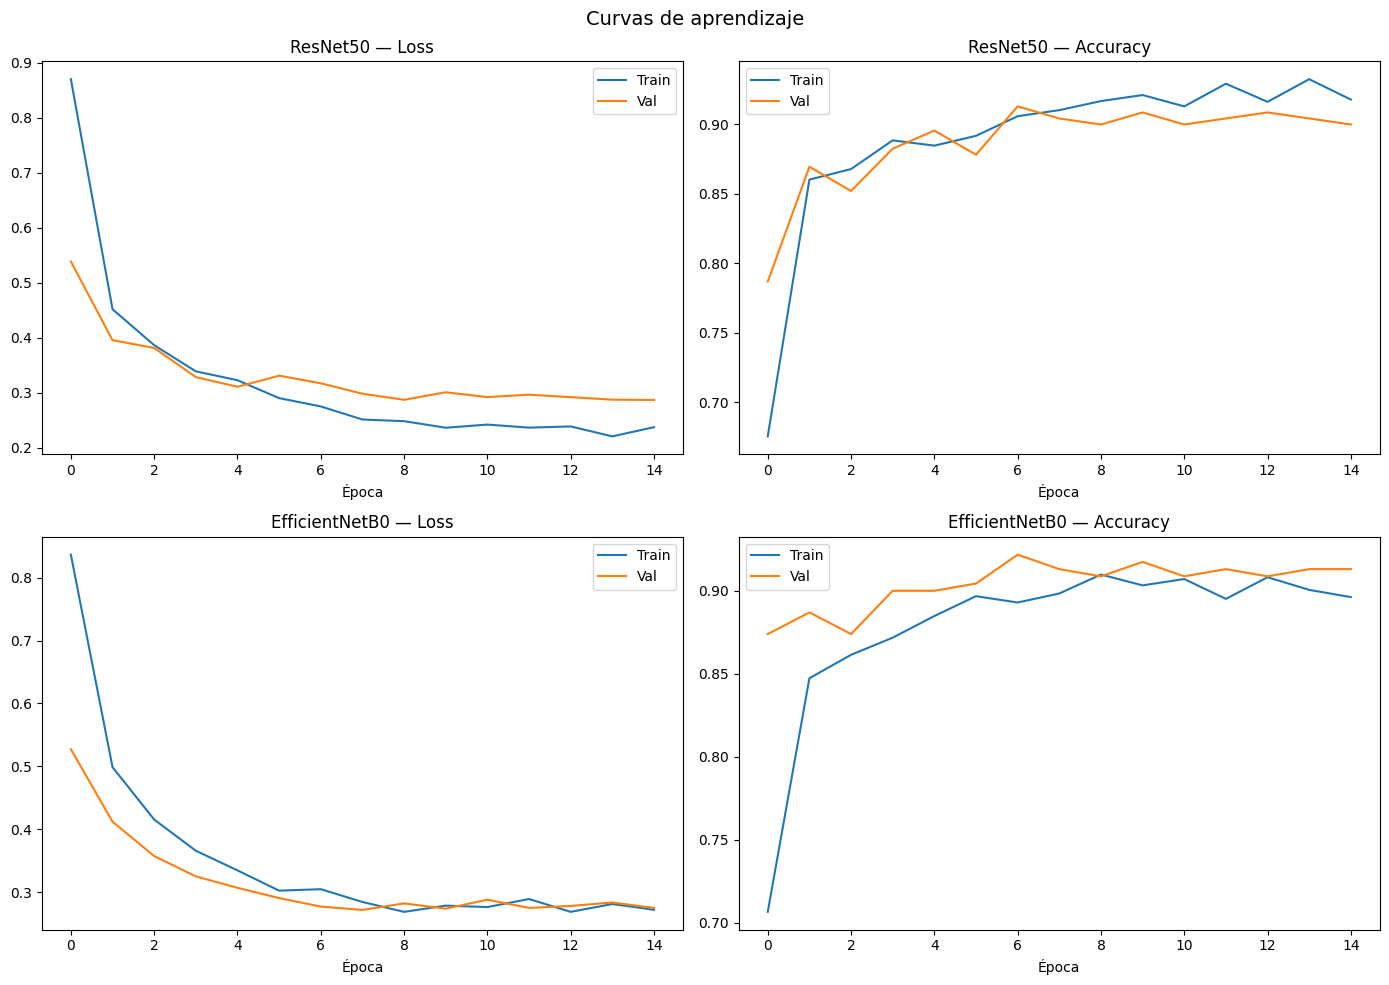

Curvas guardadas en Drive


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Curvas de aprendizaje', fontsize=14)

for i, (history, name) in enumerate([(history_res, 'ResNet50'),
                                       (history_eff, 'EfficientNetB0')]):
    axes[i][0].plot(history['train_loss'], label='Train')
    axes[i][0].plot(history['val_loss'],   label='Val')
    axes[i][0].set_title(f'{name} — Loss')
    axes[i][0].set_xlabel('Época')
    axes[i][0].legend()

    axes[i][1].plot(history['train_acc'], label='Train')
    axes[i][1].plot(history['val_acc'],   label='Val')
    axes[i][1].set_title(f'{name} — Accuracy')
    axes[i][1].set_xlabel('Época')
    axes[i][1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/curvas_aprendizaje.png', dpi=150)
plt.show()
print("Curvas guardadas en Drive")

**Evaluación en test y matrices de confusión**


  ResNet50 — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.92      0.78      0.84        45
  congestion       0.82      0.90      0.86        60
      fluido       0.92      0.90      0.91        80
       obras       0.88      0.93      0.90        45

    accuracy                           0.88       230
   macro avg       0.88      0.88      0.88       230
weighted avg       0.89      0.88      0.88       230



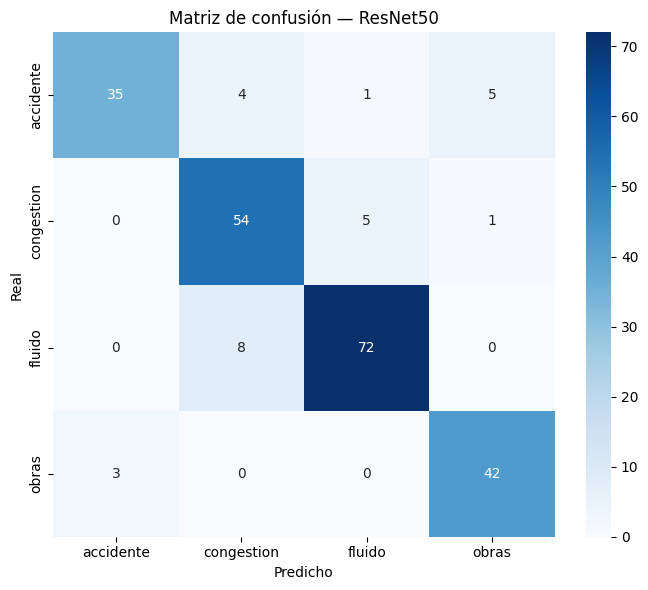


  EfficientNetB0 — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.87      0.89      0.88        45
  congestion       0.83      0.75      0.79        60
      fluido       0.86      0.86      0.86        80
       obras       0.86      0.96      0.91        45

    accuracy                           0.86       230
   macro avg       0.86      0.86      0.86       230
weighted avg       0.86      0.86      0.86       230



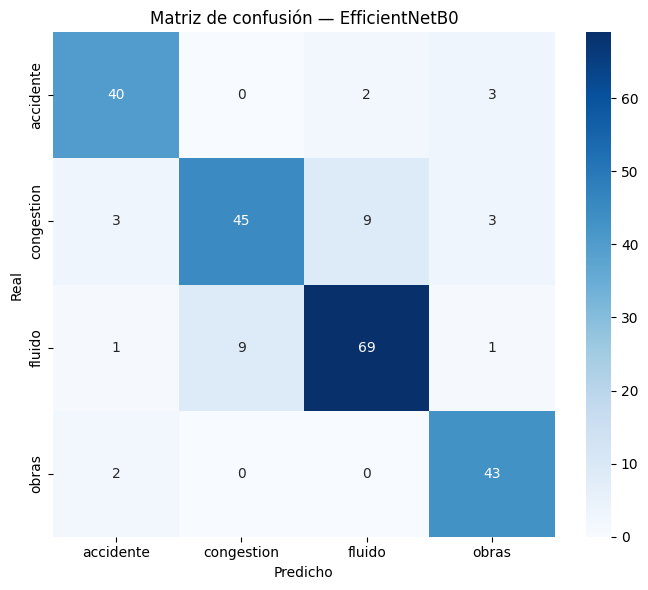

In [25]:
def evaluar_modelo(model, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f"\n{'='*45}")
    print(f"  {model_name} — Resultados en TEST")
    print(f"{'='*45}")
    print(classification_report(all_labels, all_preds,
                                 target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de confusión — {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/TFM/confusion_{model_name}.png', dpi=150)
    plt.show()

evaluar_modelo(resnet, 'ResNet50')
evaluar_modelo(efficientnet, 'EfficientNetB0')

**Baseline: CNN desde cero**

In [26]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            # Bloque 1: 224x224 -> 112x112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Bloque 2: 112x112 -> 56x56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Bloque 3: 56x56 -> 28x28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Bloque 4: 28x28 -> 14x14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline = BaselineCNN(num_classes=4).to(device)

total_params = sum(p.numel() for p in baseline.parameters())
print(f"Parámetros de la baseline CNN: {total_params:,}")

optimizer_base = optim.Adam(baseline.parameters(), lr=1e-3)
scheduler_base = optim.lr_scheduler.StepLR(optimizer_base, step_size=7, gamma=0.1)

print("\nEntrenando Baseline CNN...")
baseline, history_base = train_model(
    baseline, 'BaselineCNN', criterion,
    optimizer_base, scheduler_base, num_epochs=15
)

torch.save(baseline.state_dict(), '/content/drive/MyDrive/TFM/baseline_cnn.pth')
print("Baseline guardado en Drive")

Parámetros de la baseline CNN: 2,489,092

Entrenando Baseline CNN...
Epoch 1/15 - train loss=1.4805 acc=0.4690  val loss=1.1896 acc=0.5652  
Epoch 2/15 - train loss=0.7626 acc=0.6864  val loss=0.6763 acc=0.7304  
Epoch 3/15 - train loss=0.6450 acc=0.7288  val loss=0.5564 acc=0.8000  
Epoch 4/15 - train loss=0.5868 acc=0.7636  val loss=0.5917 acc=0.7609  
Epoch 5/15 - train loss=0.5271 acc=0.7935  val loss=0.4357 acc=0.8304  
Epoch 6/15 - train loss=0.4587 acc=0.8201  val loss=0.5434 acc=0.8087  
Epoch 7/15 - train loss=0.4445 acc=0.8408  val loss=0.3876 acc=0.8435  
Epoch 8/15 - train loss=0.3604 acc=0.8679  val loss=0.3391 acc=0.8739  
Epoch 9/15 - train loss=0.3268 acc=0.8717  val loss=0.3253 acc=0.8913  
Epoch 10/15 - train loss=0.3076 acc=0.8837  val loss=0.3316 acc=0.8913  
Epoch 11/15 - train loss=0.2955 acc=0.8902  val loss=0.3366 acc=0.8783  
Epoch 12/15 - train loss=0.2939 acc=0.8984  val loss=0.3202 acc=0.8957  
Epoch 13/15 - train loss=0.2980 acc=0.8924  val loss=0.3137 acc=

**Fine-tuning ResNet50**

In [27]:
# Cargo ResNet50 con los pesos del entrenamiento anterior
resnet_ft = models.resnet50(weights=None)
resnet_ft.fc = nn.Linear(resnet_ft.fc.in_features, 4)
resnet_ft.load_state_dict(torch.load('/content/drive/MyDrive/TFM/resnet50_tfm.pth'))
resnet_ft = resnet_ft.to(device)

# Descongelo solo layer3, layer4 y fc para el fine-tuning
for name, param in resnet_ft.named_parameters():
    if any(layer in name for layer in ['layer3', 'layer4', 'fc']):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in resnet_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet_ft.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Learning rates diferenciados: más bajo para las capas que ya tienen conocimiento
optimizer_ft = optim.Adam([
    {'params': resnet_ft.layer3.parameters(), 'lr': 1e-5},
    {'params': resnet_ft.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet_ft.fc.parameters(),     'lr': 1e-3},
])
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

print("\nEntrenando ResNet50 con fine-tuning...")
resnet_ft, history_ft = train_model(
    resnet_ft, 'ResNet50_FineTuning', criterion,
    optimizer_ft, scheduler_ft, num_epochs=15
)

torch.save(resnet_ft.state_dict(), '/content/drive/MyDrive/TFM/resnet50_finetuned.pth')
print("ResNet50 fine-tuned guardado en Drive")

Parámetros entrenables: 22,071,300 / 23,516,228 (93.9%)

Entrenando ResNet50 con fine-tuning...
Epoch 1/15 - train loss=0.3167 acc=0.8913  val loss=0.2681 acc=0.9174  
Epoch 2/15 - train loss=0.1015 acc=0.9658  val loss=0.2445 acc=0.9261  
Epoch 3/15 - train loss=0.0763 acc=0.9728  val loss=0.2556 acc=0.9304  
Epoch 4/15 - train loss=0.0488 acc=0.9821  val loss=0.3217 acc=0.9391  
Epoch 5/15 - train loss=0.0332 acc=0.9897  val loss=0.2889 acc=0.8913  
Epoch 6/15 - train loss=0.0318 acc=0.9897  val loss=0.2249 acc=0.9391  
Epoch 7/15 - train loss=0.0114 acc=0.9967  val loss=0.2010 acc=0.9391  
Epoch 8/15 - train loss=0.0075 acc=0.9984  val loss=0.2051 acc=0.9565  
Epoch 9/15 - train loss=0.0085 acc=0.9984  val loss=0.1782 acc=0.9565  
Epoch 10/15 - train loss=0.0073 acc=0.9978  val loss=0.2005 acc=0.9565  
Epoch 11/15 - train loss=0.0067 acc=0.9973  val loss=0.1945 acc=0.9522  
Epoch 12/15 - train loss=0.0051 acc=0.9989  val loss=0.1975 acc=0.9522  
Epoch 13/15 - train loss=0.0063 acc=0

**Fine-tuning EfficientNetB0**

In [28]:
efficientnet_ft = models.efficientnet_b0(weights=None)
efficientnet_ft.classifier[1] = nn.Linear(efficientnet_ft.classifier[1].in_features, 4)
efficientnet_ft.load_state_dict(torch.load('/content/drive/MyDrive/TFM/efficientnet_b0_tfm.pth'))
efficientnet_ft = efficientnet_ft.to(device)

# Descongelo los últimos bloques y el clasificador
for name, param in efficientnet_ft.named_parameters():
    if any(block in name for block in ['features.6', 'features.7', 'features.8', 'classifier']):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in efficientnet_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in efficientnet_ft.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Learning rates escalonados por profundidad
optimizer_eff_ft = optim.Adam([
    {'params': efficientnet_ft.features[6].parameters(), 'lr': 1e-5},
    {'params': efficientnet_ft.features[7].parameters(), 'lr': 1e-5},
    {'params': efficientnet_ft.features[8].parameters(), 'lr': 1e-4},
    {'params': efficientnet_ft.classifier.parameters(),  'lr': 1e-3},
])
scheduler_eff_ft = optim.lr_scheduler.StepLR(optimizer_eff_ft, step_size=5, gamma=0.1)

print("\nEntrenando EfficientNetB0 con fine-tuning...")
efficientnet_ft, history_eff_ft = train_model(
    efficientnet_ft, 'EfficientNetB0_FineTuning', criterion,
    optimizer_eff_ft, scheduler_eff_ft, num_epochs=15
)

torch.save(efficientnet_ft.state_dict(), '/content/drive/MyDrive/TFM/efficientnet_b0_finetuned.pth')
print("EfficientNetB0 fine-tuned guardado en Drive")

Parámetros entrenables: 3,160,864 / 4,012,672 (78.8%)

Entrenando EfficientNetB0 con fine-tuning...
Epoch 1/15 - train loss=0.2698 acc=0.9000  val loss=0.2708 acc=0.8870  
Epoch 2/15 - train loss=0.2407 acc=0.9136  val loss=0.2259 acc=0.9261  
Epoch 3/15 - train loss=0.1887 acc=0.9370  val loss=0.2318 acc=0.9217  
Epoch 4/15 - train loss=0.1741 acc=0.9348  val loss=0.1973 acc=0.9261  
Epoch 5/15 - train loss=0.1634 acc=0.9353  val loss=0.2149 acc=0.9304  
Epoch 6/15 - train loss=0.1392 acc=0.9440  val loss=0.2087 acc=0.9217  
Epoch 7/15 - train loss=0.1348 acc=0.9511  val loss=0.1982 acc=0.9217  
Epoch 8/15 - train loss=0.1225 acc=0.9560  val loss=0.1992 acc=0.9261  
Epoch 9/15 - train loss=0.1370 acc=0.9505  val loss=0.1930 acc=0.9217  
Epoch 10/15 - train loss=0.1326 acc=0.9538  val loss=0.2050 acc=0.9217  
Epoch 11/15 - train loss=0.1176 acc=0.9565  val loss=0.2087 acc=0.9217  
Epoch 12/15 - train loss=0.1318 acc=0.9495  val loss=0.2008 acc=0.9174  
Epoch 13/15 - train loss=0.1256 a

**Evaluación baseline y fine-tuning**


  BaselineCNN — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.83      0.89      0.86        45
  congestion       0.84      0.87      0.85        60
      fluido       0.91      0.89      0.90        80
       obras       0.93      0.87      0.90        45

    accuracy                           0.88       230
   macro avg       0.88      0.88      0.88       230
weighted avg       0.88      0.88      0.88       230



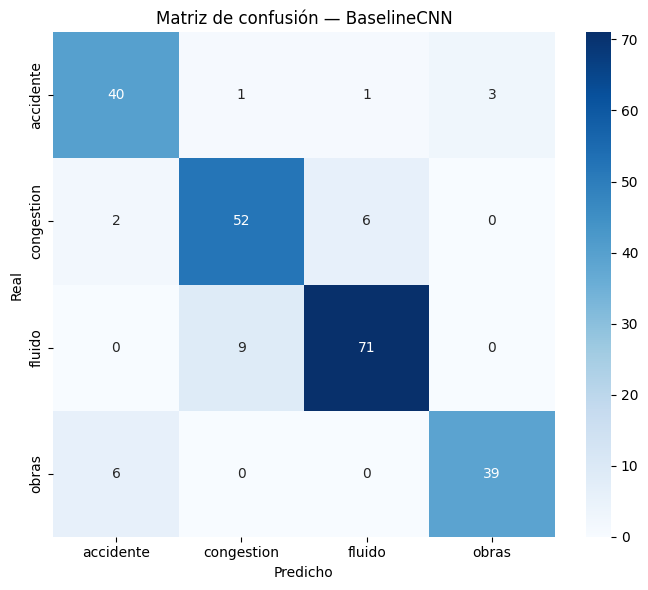


  ResNet50_FineTuning — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.98      0.96      0.97        45
  congestion       0.91      0.87      0.89        60
      fluido       0.88      0.94      0.91        80
       obras       1.00      0.98      0.99        45

    accuracy                           0.93       230
   macro avg       0.94      0.93      0.94       230
weighted avg       0.93      0.93      0.93       230



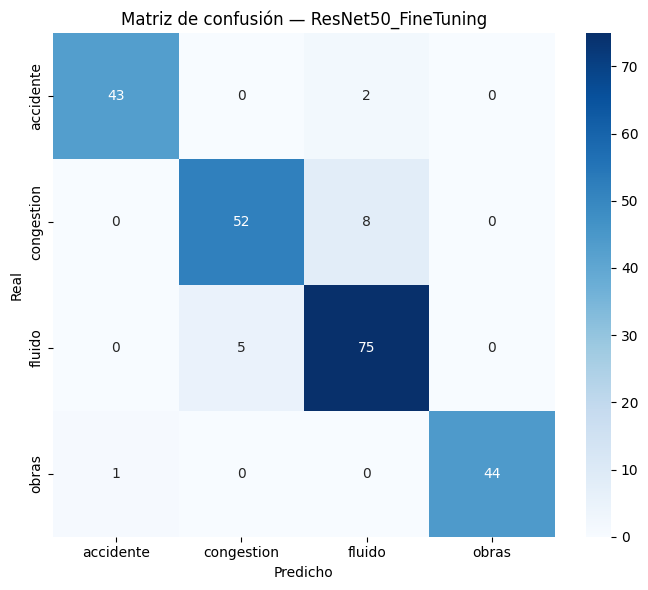


  EfficientNetB0_FineTuning — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.95      0.87      0.91        45
  congestion       0.83      0.87      0.85        60
      fluido       0.90      0.89      0.89        80
       obras       0.94      0.98      0.96        45

    accuracy                           0.90       230
   macro avg       0.90      0.90      0.90       230
weighted avg       0.90      0.90      0.90       230



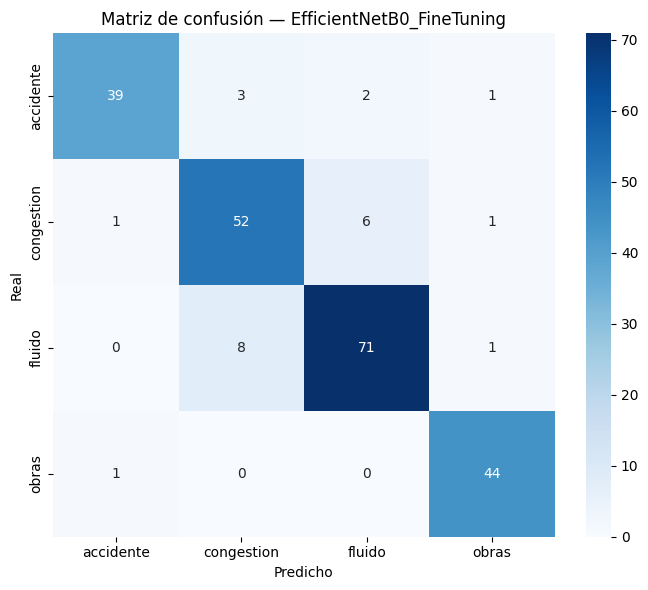

In [29]:
evaluar_modelo(baseline, 'BaselineCNN')
evaluar_modelo(resnet_ft, 'ResNet50_FineTuning')
evaluar_modelo(efficientnet_ft, 'EfficientNetB0_FineTuning')

**Tabla comparativa**

In [30]:
from sklearn.metrics import accuracy_score, f1_score

def get_metrics(model):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

print("=" * 55)
print(f"  {'Modelo':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("=" * 55)

modelos = [
    (baseline,        'Baseline CNN'),
    (resnet,          'ResNet50 (Transfer)'),
    (resnet_ft,       'ResNet50 (Fine-tuning)'),
    (efficientnet,    'EfficientNetB0 (Transfer)'),
    (efficientnet_ft, 'EfficientNetB0 (Fine-tuning)'),
]

for model, name in modelos:
    acc, f1 = get_metrics(model)
    print(f"  {name:<25} {acc:>10.4f} {f1:>10.4f}")

print("=" * 55)

  Modelo                      Accuracy   Macro F1
  Baseline CNN                  0.8783     0.8770
  ResNet50 (Transfer)           0.8826     0.8788
  ResNet50 (Fine-tuning)        0.9304     0.9383
  EfficientNetB0 (Transfer)     0.8565     0.8591
  EfficientNetB0 (Fine-tuning)     0.8957     0.9005


**Curvas comparativas**

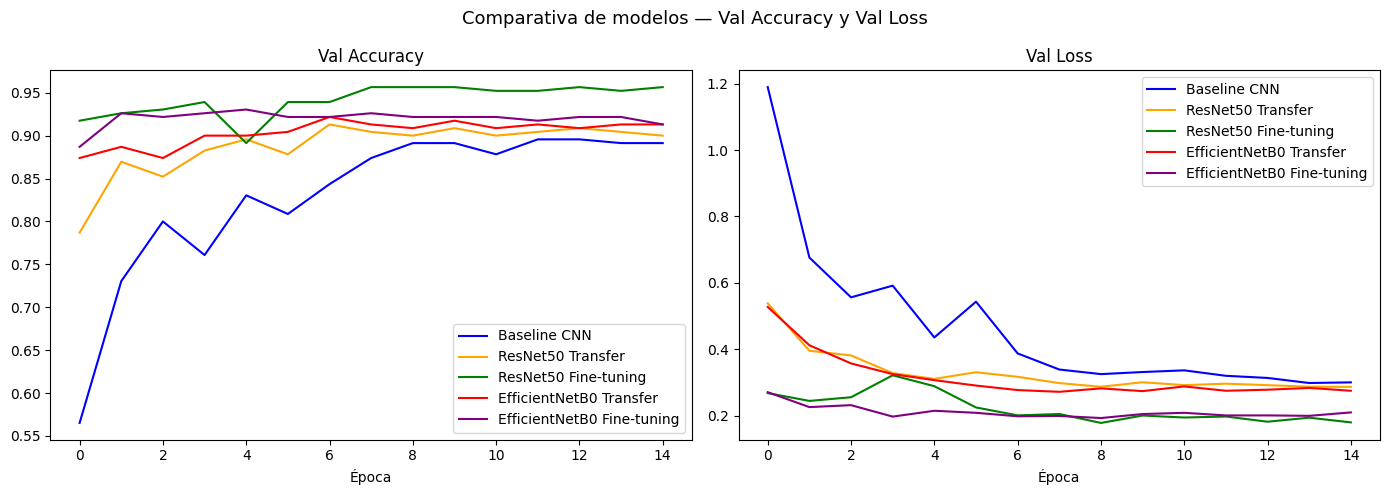

Comparativa guardada en Drive


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparativa de modelos — Val Accuracy y Val Loss', fontsize=13)

configs = [
    (history_base,    'Baseline CNN',                  'blue'),
    (history_res,     'ResNet50 Transfer',              'orange'),
    (history_ft,      'ResNet50 Fine-tuning',           'green'),
    (history_eff,     'EfficientNetB0 Transfer',        'red'),
    (history_eff_ft,  'EfficientNetB0 Fine-tuning',     'purple'),
]

for history, name, color in configs:
    axes[0].plot(history['val_acc'],  label=name, color=color)
    axes[1].plot(history['val_loss'], label=name, color=color)

axes[0].set_title('Val Accuracy')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].set_title('Val Loss')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/comparativa_modelos.png', dpi=150)
plt.show()
print("Comparativa guardada en Drive")